In [1]:
# общие импорты
import numpy as np
# import pandas as pd
import altair as alt
import polars as pl
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
import duckdb as dd

conn = dd.connect()

In [3]:
users_db = "../data/raw/VK-LSVD/metadata/users_metadata.parquet"
items_db = "../data/raw/VK-LSVD/metadata/items_metadata.parquet"
bhv_db = "../data/raw/VK-LSVD/subsamples/up0.001_ip0.001/train/week_*.parquet"

# Eexploratory Data Analysis

## Данные о пользователях

In [4]:
df_users = pl.read_parquet(users_db)

In [5]:
df_users.describe()

statistic,user_id,age,gender,geo,train_interactions_rank
str,f64,f64,f64,f64,f64
"""count""",1e7,1e7,1e7,1e7,1e7
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",2.5506e8,36.724947,1.5572987,64.099335,4999999.5
"""std""",1.4726e8,12.783832,0.496706,18.113934,2.8868e6
"""min""",59.0,18.0,1.0,0.0,0.0
"""25%""",1.27529684e8,26.0,1.0,58.0,2.5e6
"""50%""",2.5508687e8,35.0,2.0,71.0,5e6
"""75%""",3.82589358e8,45.0,2.0,77.0,7.499999e6
"""max""",5.10119695e8,70.0,2.0,79.0,9.999999e6


Пропусков в таблице нет, количество значений в колонках везде соответствует количеству записей. 

Пользователи совершеннолетние, от 18 до 70 лет. 

Более 75% пользователей имеют собственный доход, про остальных непонятно. 

Более 50% принадлежат полу с id 2. 

Неожиданно, но больше 50% пользователей относятся к 6 регионам (регионов в россии где - то за 80, да и в описании явно сказано, что некоторые регионы были укрупнены).

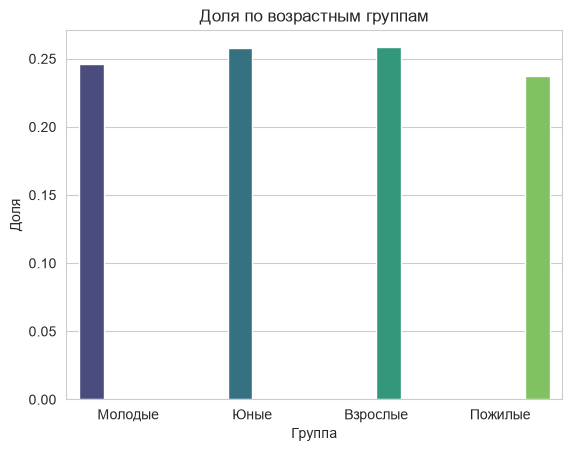

In [6]:
breaks = [26, 35, 45]
labels = ["Юные", "Молодые", "Взрослые", "Пожилые"]
df_users = df_users.with_columns(
    pl.col("age")
    .cut(breaks=breaks, labels=labels)
    .cast(pl.Categorical) # Приводим к типу Categorical для оптимизации памяти
    .alias("age_category")
)
df_counts = (
    df_users.group_by("age_category")
    .agg(count = pl.len())
    .with_columns(share = pl.col("count") / pl.col("count").sum())
    .sort(pl.col("age_category").to_physical())
)

sns.barplot(data=df_counts.to_pandas(), x="age_category", y="share", palette="viridis", hue="age_category", legend=False)

plt.title("Доля по возрастным группам")
plt.xlabel("Группа")
plt.ylabel("Доля")
plt.show()

Количественно, все группы примерно равны.

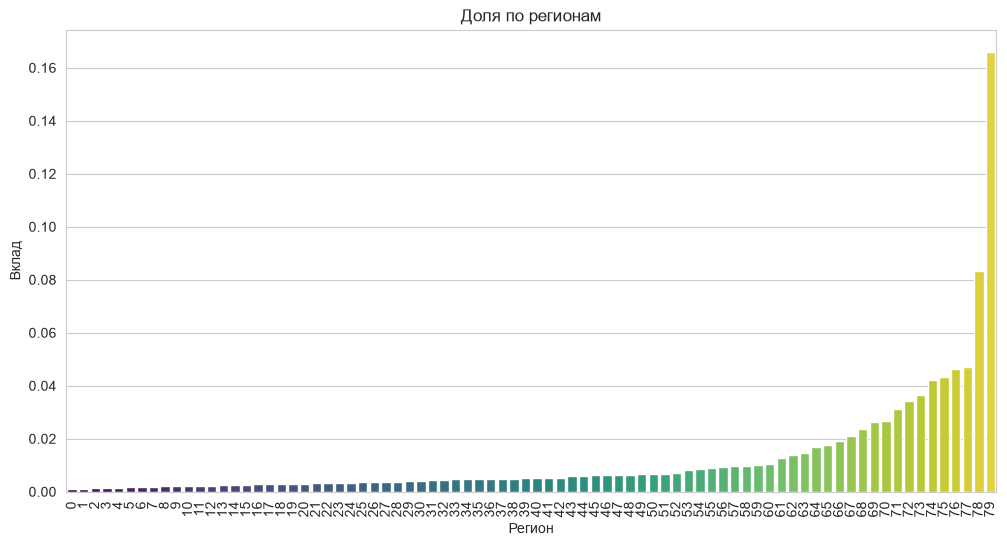

In [7]:
df_counts = (
    df_users.group_by("geo")
    .agg(count = pl.len())
    .with_columns(share = pl.col("count") / pl.col("count").sum())
    .sort(pl.col("geo").to_physical())
)

plt.figure(figsize=(12, 6))
plt.xticks(rotation=90, fontsize=10)
sns.barplot(data=df_counts.to_pandas(), x="geo", y="share", palette="viridis", hue="geo", legend=False)

plt.title("Доля по регионам")
plt.xlabel("Регион")
plt.ylabel("Вклад")
plt.show()

Один регион явно отрывается от остальных, возможно здесь находятся все те регионы, размер которых оказался недостаточен, чтобы стоять на отдельной строке, а может все так и есть, и, например в Москве, на столько больше пользователей vk сервисов, что остальным еще есть куда расти.

Доли мальчиков и девочек примерно равны и мы не станем обращать внимание на детали в этом моменте.

## Данные о фильмах/роликах

In [8]:
df_items = pl.read_parquet(items_db)

In [9]:
df_items.describe()

statistic,item_id,author_id,duration,train_interactions_rank
str,f64,f64,f64,f64
"""count""",1.9627601e7,1.9627601e7,1.9627601e7,1.9627601e7
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",3.0403e8,665026.182039,34.113191,9.8138e6
"""std""",1.7552e8,371168.869733,29.769534,5.6660e6
"""min""",38.0,558.0,5.0,0.0
"""25%""",1.52032851e8,300052.0,12.0,4.9069e6
"""50%""",3.04032967e8,656479.0,24.0,9.8138e6
"""75%""",4.56029226e8,1.008023e6,50.0,1.47207e7
"""max""",6.08066952e8,1.278886e6,180.0,1.96276e7


In [10]:
len(df_items.unique(['author_id'])), len(df_items)

(439521, 19627601)

Пропусков в данных нет. 

Четверь толиков имеет длительность менее 15 секунд, остальные - больше. 

Таблица связывает автора с роликами.

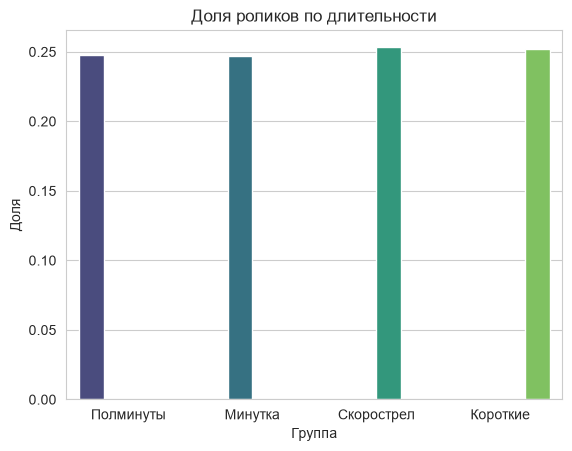

In [11]:
breaks = [12, 24, 50]
labels = ["Скорострел", "Короткие", "Полминуты", "Минутка"]
df_items = df_items.with_columns(
    pl.col("duration")
    .cut(breaks=breaks, labels=labels)
    .cast(pl.Categorical) # Приводим к типу Categorical для оптимизации памяти
    .alias("duration_category")
)
df_counts = (
    df_items.group_by("duration_category")
    .agg(count = pl.len())
    .with_columns(share = pl.col("count") / pl.col("count").sum())
    .sort(pl.col("duration_category").to_physical())
)

sns.barplot(data=df_counts.to_pandas(), x="duration_category", y="share", palette="viridis", hue="duration_category", legend=False)

plt.title("Доля роликов по длительности")
plt.xlabel("Группа")
plt.ylabel("Доля")
plt.show()

In [12]:
distribution = (
    df_items
    .group_by("author_id")
    .agg(pl.len().alias("video_count"))
    .sort("video_count", descending=True)
)
distribution.describe()

statistic,author_id,video_count
str,f64,f64
"""count""",439521.0,439521.0
"""null_count""",0.0,0.0
"""mean""",697944.541476,44.656799
"""std""",362505.808694,172.908169
"""min""",558.0,1.0
"""25%""",384158.0,5.0
"""50%""",714286.0,11.0
"""75%""",1.019144e6,27.0
"""max""",1.278886e6,9110.0


In [13]:
z = df_items.group_by("author_id").agg(pl.len())["len"].value_counts(sort=True)
z

len,count
u32,u32
1,29345
2,23636
7,23575
6,22243
3,21701
…,…
2264,1
2493,1
2870,1


## Поведение пользователей

In [14]:
df_meta = pl.read_parquet(bhv_db)
df_meta.describe()

statistic,user_id,item_id,place,platform,agent,timespent,like,dislike,share,bookmark,click_on_author,open_comments
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",4.7068641e7,4.7068641e7,4.7068641e7,4.7068641e7,4.7068641e7,4.7068641e7,4.7068641e7,4.7068641e7,4.7068641e7,4.7068641e7,4.7068641e7,4.7068641e7
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2.5381e8,3.0524e8,0.795249,0.47658,0.419594,15.484879,0.009642,0.000395,0.00268,0.000408,0.00109,0.015181
"""std""",1.4669e8,1.7574e8,0.665252,0.892576,0.699888,23.060433,null,null,null,null,null,null
"""min""",20125.0,66761.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",1.27705185e8,1.5120488e8,0.0,0.0,0.0,2.0,null,null,null,null,null,null
"""50%""",2.52925743e8,3.06262984e8,1.0,0.0,0.0,6.0,null,null,null,null,null,null
"""75%""",3.8035104e8,4.57115811e8,1.0,1.0,1.0,18.0,null,null,null,null,null,null
"""max""",5.10091816e8,6.0803424e8,23.0,10.0,21.0,255.0,1.0,1.0,1.0,1.0,1.0,1.0


Пропусков в данных нет.

Таблица связывает действия пользователя с фильмом. 

При всем богатстве выбора place имеем только 2 источника, с которых народ переходил, если предположить что 0 является заполнителем, то и вовсе один.

Из всех возможных platform, задействованы тоже всего 2.

Агентов agent тоже всего 2.

Пожалуй самое важное поле, timespent, сколько пользователь смотрел конкретный ролик. Видим, как минимум четверь роликов попадают в первую перценталь и не выходят за пределы зачетных 5 секунд.

Далее идут поля пользовательских действий: активно понравилось или активно не понравилось, форварднул, сохранил, посмотрел данные автора, открыл коментарии.

### Гипотезы о данных